# Chapter 45 — Uncertainty Fundamentals
### *Modern Strain Gage Technology* — Companion Notebook

**Every measurement is a claim, and every honest claim states how well it is known.** This notebook turns the GUM framework of Chapter 45 into runnable code: it evaluates Type A and Type B uncertainties, combines them by root sum of squares, and expands the result into a reported interval — reproducing the chapter's worked strain-measurement budget number for number.

Companion notebook to Chapter 45 — Uncertainty Fundamentals.

**What this notebook builds:**
1. **Type A** — a standard uncertainty from repeated readings (Eq. 45.1).
2. **Type B** — standard uncertainties from a stated coverage level (Eq. 45.2) and from a rectangular distribution (Eq. 45.3).
3. **The budget** — the five independent sources of the chapter's worked example, combined by RSS (Eq. 45.4) and expanded to *U = k·u_c* at *k* = 2 (Eq. 45.5).

In [1]:
# Colab: uncomment to install dependencies
# !pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

# This notebook is fully deterministic: every input is either a fixed
# specification or a hard-coded set of readings, so no random seed is needed.

# Plot styling for the inline budget chart later in the notebook.
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
})

---
## 1 — Type A: a standard uncertainty from repeated readings

A *Type A* uncertainty is evaluated by the statistical analysis of repeated observations. Take *n* readings of the same quantity under the same conditions, compute their sample standard deviation *s*, and the standard uncertainty of the *mean* is *s* divided by the square root of *n*:

$$u_A = \frac{s}{\sqrt{n}} \qquad (45.1)$$

In plain English: averaging beats down random scatter, but only slowly — you must quadruple the number of readings to halve this contribution. The ten back-to-back readings below scatter by about 2.6 με, yet the uncertainty of their *mean* is already under 1 με. That is why, in the full budget later, repeatability turns out to be one of the smallest terms.

In [2]:
def type_a_uncertainty(readings):
    """Type A standard uncertainty of the mean (Eq. 45.1: u_A = s / sqrt(n)).

    Parameters
    ----------
    readings : array_like
        Repeated observations of one quantity taken under the same conditions.

    Returns
    -------
    mean : float
        Best estimate of the quantity (the sample mean).
    s : float
        Experimental (sample) standard deviation, computed with ddof=1.
    u_a : float
        Standard uncertainty of the mean, in the same units as the readings.
    """
    readings = np.asarray(readings, dtype=float)
    n = readings.size
    mean = readings.mean()
    s = readings.std(ddof=1)          # sample (experimental) standard deviation
    u_a = s / np.sqrt(n)              # a.k.a. the standard error of the mean
    return mean, s, u_a


# Ten repeat readings of a nominally constant strain (με), taken back-to-back.
# Hard-coded so the demonstration is fully reproducible.
REPEAT_READINGS_UE = np.array(
    [1002, 998, 1005, 1001, 999, 1003, 997, 1004, 1000, 1002], dtype=float
)

mean_ue, s_ue, u_a_ue = type_a_uncertainty(REPEAT_READINGS_UE)
print(f"Type A evaluation of {REPEAT_READINGS_UE.size} repeat readings")
print(f"  mean  x_bar       = {mean_ue:8.2f} με")
print(f"  sample std dev s  = {s_ue:8.3f} με")
print(f"  u_A = s / sqrt(n) = {u_a_ue:8.3f} με")

Type A evaluation of 10 repeat readings
  mean  x_bar       =  1001.10 με
  sample std dev s  =    2.601 με
  u_A = s / sqrt(n) =    0.823 με


---
## 2 — Type B: standard uncertainties from specifications

A *Type B* uncertainty is evaluated from any source other than repeated observation — a calibration certificate, a datasheet tolerance, an instrument's resolution, or physical reasoning about the limits of a quantity. The task is always the same: convert a stated specification into a standard-deviation equivalent.

Two cases cover most of strain measurement. When a certificate quotes an **expanded uncertainty** *U* at coverage factor *k* (assuming a normal distribution), divide it back down to a standard uncertainty:

$$u_B = \frac{U}{k} \qquad (45.2)$$

When only the **limits** ±*a* are known and no value inside them is more likely than another, model the quantity as a rectangular (uniform) distribution, whose standard deviation is *a* over the square root of three:

$$u_B = \frac{a}{\sqrt{3}} \qquad (45.3)$$

The two small helper functions below encapsulate these conversions. The printed examples reproduce the chapter's figures — a ±0.5 % gage-factor tolerance at *k* = 2 becomes 2.50 με, and a ±1 με resolution limit becomes 0.577 με, not the full 1 με.

In [3]:
SQRT3 = np.sqrt(3.0)


def u_from_expanded(U, k=2.0):
    """Type B standard uncertainty from a stated expanded uncertainty (Eq. 45.2).

    A calibration certificate or datasheet that quotes an expanded uncertainty U
    at coverage factor k (assuming a normal distribution) implies a standard
    uncertainty u_B = U / k.
    """
    return U / k


def u_rectangular(a):
    """Type B standard uncertainty for a rectangular (uniform) distribution (Eq. 45.3).

    When only the half-width limits +/-a are known and no value inside them is
    more likely than another, the standard uncertainty is a / sqrt(3).
    """
    return a / SQRT3


# Mini-examples straight from the chapter, to sanity-check the conversions:
print("Type B from a stated expanded uncertainty (Eq. 45.2):")
print(f"  Gage factor  +/-0.5%  of 1000 με at k=2 -> u = {u_from_expanded(0.005 * 1000, k=2):.2f} με")
print(f"  Completion   +/-0.02% of 1000 με at k=2 -> u = {u_from_expanded(0.0002 * 1000, k=2):.2f} με")
print()
print("Type B from a rectangular distribution (Eq. 45.3):")
print(f"  Resolution   +/-1.0 με                  -> u = {u_rectangular(1.0):.3f} με")
print(f"  Resolution   +/-0.5 με                  -> u = {u_rectangular(0.5):.3f} με")

Type B from a stated expanded uncertainty (Eq. 45.2):
  Gage factor  +/-0.5%  of 1000 με at k=2 -> u = 2.50 με
  Completion   +/-0.02% of 1000 με at k=2 -> u = 0.10 με

Type B from a rectangular distribution (Eq. 45.3):
  Resolution   +/-1.0 με                  -> u = 0.577 με
  Resolution   +/-0.5 με                  -> u = 0.289 με


---
## 3 — The uncertainty budget: combining and expanding

A real strain measurement draws on many independent sources at once. When those sources are uncorrelated, the GUM combines them into a single *combined standard uncertainty* by root sum of squares, each term weighted by its sensitivity coefficient *cᵢ* — the partial derivative of the result with respect to that input:

$$u_c = \sqrt{\sum_i (c_i\,u_i)^2} \qquad (45.4)$$

For a higher confidence level, multiply by a coverage factor *k* to obtain the *expanded uncertainty*:

$$U = k\,u_c \qquad (45.5)$$

The chapter's worked example is a uniaxial quarter-bridge measurement with five sources (Table 45.2). Every source is already expressed in output microstrain, so every sensitivity coefficient is unity and the RSS collapses to the root sum of the *uᵢ* themselves. Reproducing it below yields *u_c* ≈ 3.15 με and, at *k* = 2, an expanded uncertainty *U* ≈ 6.3 με — reported as **1000 ± 6.3 με (k = 2, ~95 % confidence)**. The `var share` column makes the chapter's punchline visible: gage-factor tolerance and thermal output together account for about 93 % of the combined variance, so that is where any real decrease has to come from — not from a better digitizer.

In [4]:
# --- The chapter's five-source uncertainty budget (Table 45.2) ----------------
# Every source is expressed directly in output microstrain, so each sensitivity
# coefficient c_i = 1 and the RSS reduces to the root sum of the u_i themselves.

NOMINAL_STRAIN_UE = 1000.0        # nominal reading the budget is evaluated at
COVERAGE_FACTOR_K = 2.0           # k = 2 -> approximately 95% confidence

# Repeatability (Source 5, Type A): the chapter characterizes it by s and n.
REPEAT_S_UE = 1.8                 # sample std dev of 10 repeat load applications
REPEAT_N    = 10

# Each row: (source name, standard uncertainty u_i [με], type, distribution)
budget = [
    ("Gage factor tolerance",   u_from_expanded(0.0050 * NOMINAL_STRAIN_UE, k=2), "B", "normal, k=2"),
    ("Instrument gain",         u_from_expanded(0.0010 * NOMINAL_STRAIN_UE, k=2), "B", "normal, k=2"),
    ("Thermal output",          u_rectangular(3.0),                               "B", "rectangular"),
    ("Digitizer resolution",    u_rectangular(0.5),                               "B", "rectangular"),
    ("Repeatability",           REPEAT_S_UE / np.sqrt(REPEAT_N),                  "A", "normal"),
]


def combine_rss(standard_uncertainties):
    """Combined standard uncertainty by root sum of squares (Eq. 45.4 with c_i = 1)."""
    u = np.asarray(standard_uncertainties, dtype=float)
    return np.sqrt(np.sum(u**2))


u_i = np.array([row[1] for row in budget])
u_c = combine_rss(u_i)
U_expanded = COVERAGE_FACTOR_K * u_c

# --- Print the budget as a table ---------------------------------------------
print(f"{'Source':<24}{'Type':<6}{'Distribution':<14}{'u_i (με)':>10}{'var share':>11}")
print("-" * 65)
for name, u, typ, dist in budget:
    var_share = u**2 / u_c**2
    print(f"{name:<24}{typ:<6}{dist:<14}{u:>10.3f}{var_share:>10.1%}")
print("-" * 65)
print(f"{'Combined standard uncertainty u_c':<54}{u_c:>10.3f} με")
print(f"{'Expanded uncertainty U = k*u_c (k=2, ~95%)':<54}{U_expanded:>10.3f} με")
print()
print(f"Reported result: {NOMINAL_STRAIN_UE:.0f} +/- {U_expanded:.1f} με "
      f"(k={COVERAGE_FACTOR_K:.0f}, ~95% confidence)")

Source                  Type  Distribution    u_i (με)  var share
-----------------------------------------------------------------
Gage factor tolerance   B     normal, k=2        2.500     63.1%
Instrument gain         B     normal, k=2        0.500      2.5%
Thermal output          B     rectangular        1.732     30.3%
Digitizer resolution    B     rectangular        0.289      0.8%
Repeatability           A     normal             0.569      3.3%
-----------------------------------------------------------------
Combined standard uncertainty u_c                          3.148 με
Expanded uncertainty U = k*u_c (k=2, ~95%)                 6.295 με

Reported result: 1000 +/- 6.3 με (k=2, ~95% confidence)


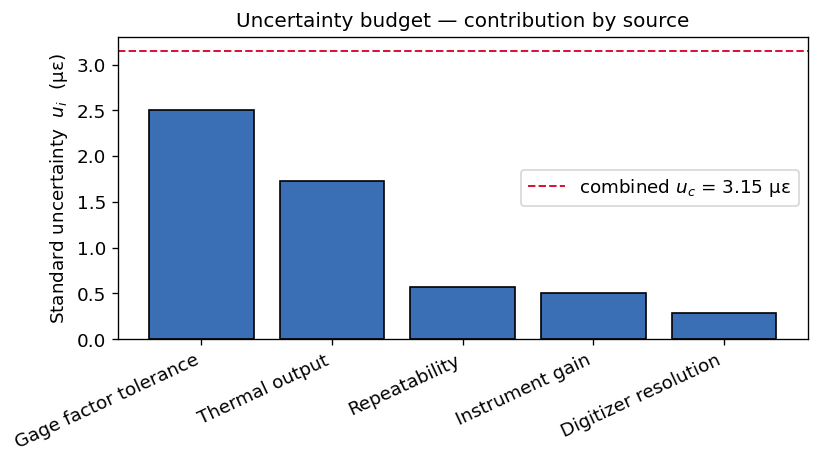

In [5]:
# Which sources dominate the budget? (The chapter's central diagnostic point.)
# Inline chart only -- this notebook intentionally saves no figure to disk.
names = np.array([row[0] for row in budget])
order = np.argsort(u_i)[::-1]            # largest contribution first

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names[order], u_i[order], color="#3b6fb5", edgecolor="black")
ax.axhline(u_c, color="crimson", linestyle="--", linewidth=1.2,
           label=f"combined $u_c$ = {u_c:.2f} με")
ax.set_ylabel("Standard uncertainty  $u_i$  (με)")
ax.set_title("Uncertainty budget — contribution by source")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend()
fig.tight_layout()
plt.show()

---
## 4 — Figure 45.1: a budget with sensitivity coefficients

The five-source budget above expresses every contributor directly in microstrain, so
each sensitivity coefficient is 1 and the combination is a plain root-sum-of-squares.
Real budgets are rarely that tidy: the inputs arrive in volts, ohms, degrees and
degrees Celsius, and each needs a *sensitivity coefficient* — the partial derivative of
strain with respect to that input — to convert it into strain units.

The point worth pausing on is that **several of those coefficients depend on the strain
being measured.** Gage-factor tolerance and excitation-voltage error are *ratiometric*:
a ±0.5 % gage factor is ±5 µε at 1,000 µε and ±0.5 µε at 100 µε. A budget of this kind
is therefore only meaningful at a stated measurement point, and the point has to be
quoted alongside it. Everything below is derived from one — an indicated 1,000 µε on a
350 Ω quarter bridge — rather than typed in.

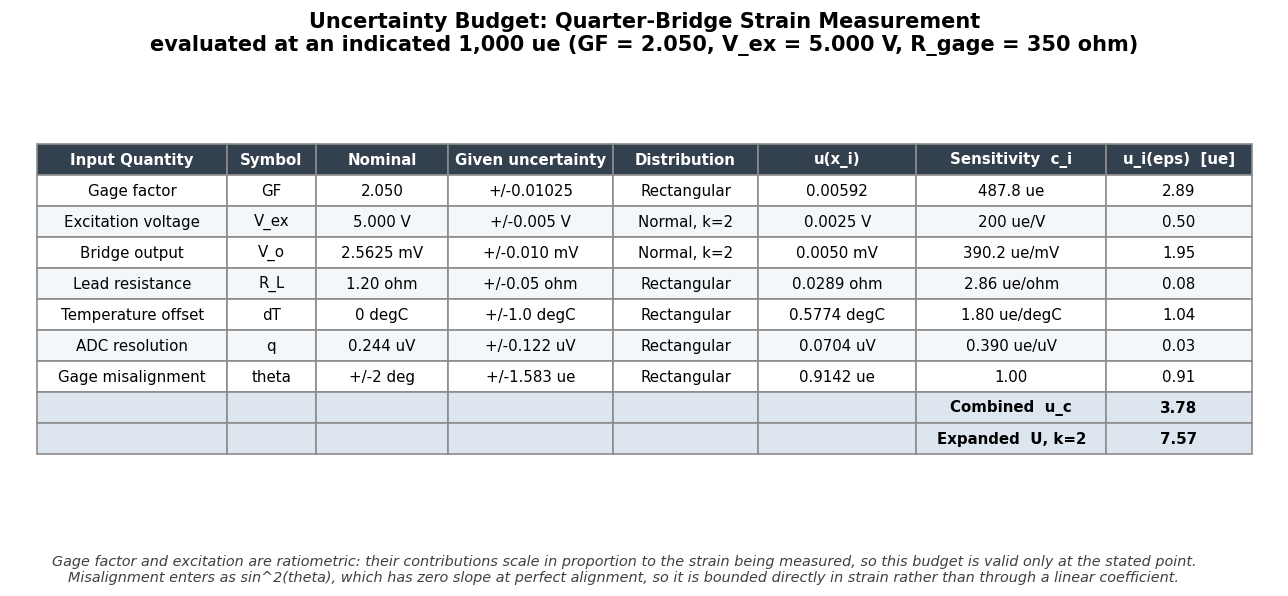

combined u_c = 3.783 ue;  U(k=2) = 7.567 ue (0.76 % of 1,000 ue)
dominant: Gage factor 2.89, Bridge output 1.95, Temperature offset 1.04


In [6]:
# --- Figure 45.1: quarter-bridge budget with non-unit sensitivity coefficients ---
# Every entry below is COMPUTED from the measurement point, so the table cannot drift
# out of agreement with itself.
import os

EPS_UE   = 1000.0     # indicated strain the budget is evaluated at, microstrain
GF       = 2.050      # gage factor
V_EX     = 5.000      # excitation, V
R_GAGE   = 350.0      # gage resistance, ohm
NU       = 0.30       # Poisson's ratio of the specimen
ADC_LSB  = 0.244      # ADC least significant bit, uV
STC_RATE = 1.8        # residual thermal output of an STC-matched gage, ue/degC
THETA_D  = 2.0        # alignment tolerance, degrees

# Quarter bridge: eps = 4 Vo / (GF Vex)  ->  the nominal output follows from the point.
V_O_MV = EPS_UE * 1e-6 * GF * V_EX / 4.0 * 1e3        # mV

SQRT3, SQRT12 = np.sqrt(3.0), np.sqrt(12.0)

# Sensitivity coefficients, each d(eps)/d(x) in microstrain per unit of x.
c_GF    = EPS_UE / GF                  # ue per unit GF   (ratiometric in eps)
c_VEX   = EPS_UE / V_EX                # ue per V         (ratiometric in eps)
c_VO    = 4.0 / (GF * V_EX) * 1e6 / 1e3   # ue per mV
c_RL    = EPS_UE / R_GAGE              # ue per ohm
c_DT    = STC_RATE                     # ue per degC
c_Q     = 4.0 / (GF * V_EX) * 1e6 / 1e6   # ue per uV
# Misalignment enters as sin^2(theta): a linear coefficient at theta = 0 would be zero,
# so bound it directly in strain instead.
MIS_UE  = (1 + NU) * EPS_UE * np.sin(np.radians(THETA_D))**2

# name, symbol, nominal, given half-width (display), distribution, divisor,
# u(x) display, sensitivity display, c_i, u(x) numeric
R = [
 ("Gage factor",        "GF",    f"{GF:.3f}",          f"+/-{0.005*GF:.5f}",  "Rectangular", SQRT3,
  lambda u: f"{u:.5f}",            f"{c_GF:,.1f} ue",        c_GF,  0.005*GF),
 ("Excitation voltage", "V_ex",  f"{V_EX:.3f} V",      "+/-0.005 V",          "Normal, k=2", 2.0,
  lambda u: f"{u:.4f} V",          f"{c_VEX:,.0f} ue/V",     c_VEX, 0.005),
 ("Bridge output",      "V_o",   f"{V_O_MV:.4f} mV",   "+/-0.010 mV",         "Normal, k=2", 2.0,
  lambda u: f"{u:.4f} mV",         f"{c_VO:,.1f} ue/mV",     c_VO,  0.010),
 ("Lead resistance",    "R_L",   "1.20 ohm",           "+/-0.05 ohm",         "Rectangular", SQRT3,
  lambda u: f"{u:.4f} ohm",        f"{c_RL:,.2f} ue/ohm",    c_RL,  0.05),
 ("Temperature offset", "dT",    "0 degC",             "+/-1.0 degC",         "Rectangular", SQRT3,
  lambda u: f"{u:.4f} degC",       f"{c_DT:,.2f} ue/degC",   c_DT,  1.0),
 # quantization: the error is uniform over one LSB, i.e. +/- half an LSB
 ("ADC resolution",     "q",     f"{ADC_LSB:.3f} uV",  f"+/-{ADC_LSB/2:.3f} uV","Rectangular", SQRT3,
  lambda u: f"{u:.4f} uV",         f"{c_Q:,.3f} ue/uV",      c_Q,   ADC_LSB / 2),
 ("Gage misalignment",  "theta", f"+/-{THETA_D:.0f} deg", f"+/-{MIS_UE:.3f} ue", "Rectangular", SQRT3,
  lambda u: f"{u:.4f} ue",         "1.00",                   1.0,   MIS_UE),
]

table, u_all = [], []
for name, sym, nom, given, dist, div, ufmt, cdisp, c_i, halfwidth in R:
    u_x = halfwidth / div
    u_i = u_x * c_i
    u_all.append(u_i)
    table.append([name, sym, nom, given, dist, ufmt(u_x), cdisp, f"{u_i:.2f}"])

u_c = float(np.sqrt(np.sum(np.square(u_all))))
U   = 2.0 * u_c
table.append(["", "", "", "", "", "", "Combined  u_c", f"{u_c:.2f}"])
table.append(["", "", "", "", "", "", "Expanded  U, k=2", f"{U:.2f}"])

fig, ax = plt.subplots(figsize=(13.6, 4.8))
ax.axis("off")
cols = ["Input Quantity", "Symbol", "Nominal", "Given uncertainty",
        "Distribution", "u(x_i)", "Sensitivity  c_i", "u_i(eps)  [ue]"]
tb = ax.table(cellText=table, colLabels=cols, cellLoc="center", loc="center",
              colWidths=[0.150, 0.070, 0.105, 0.130, 0.115, 0.125, 0.150, 0.115])
tb.auto_set_font_size(False); tb.set_fontsize(9.0); tb.scale(1, 1.55)
for (r, c), cell in tb.get_celld().items():
    cell.set_edgecolor("0.55")
    if r == 0:
        cell.set_facecolor("#33404d"); cell.set_text_props(color="white", weight="bold")
    elif r > len(R):
        cell.set_facecolor("#dde6ef"); cell.set_text_props(weight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f4f7fa")

ax.set_title("Uncertainty Budget: Quarter-Bridge Strain Measurement\n"
             f"evaluated at an indicated {EPS_UE:,.0f} ue "
             f"(GF = {GF:.3f}, V_ex = {V_EX:.3f} V, R_gage = {R_GAGE:.0f} ohm)",
             fontsize=12.5, weight="bold", pad=16)
fig.text(0.5, 0.005,
         "Gage factor and excitation are ratiometric: their contributions scale in "
         "proportion to the strain being measured, so this budget is valid only at the "
         "stated point.\nMisalignment enters as sin^2(theta), which has zero slope at "
         "perfect alignment, so it is bounded directly in strain rather than through a "
         "linear coefficient.",
         ha="center", fontsize=8.6, style="italic", color="0.25")

out = os.path.join("..", "src", "media", "ch45")
os.makedirs(out, exist_ok=True)
fig.savefig(os.path.join(out, "fig45_nb2_uncertainty_budget.png"),
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"combined u_c = {u_c:.3f} ue;  U(k=2) = {U:.3f} ue "
      f"({U/EPS_UE*100:.2f} % of {EPS_UE:,.0f} ue)")
order = np.argsort(u_all)[::-1]
print("dominant:", ", ".join(f"{R[i][0]} {u_all[i]:.2f}" for i in order[:3]))


---
## Where to take this next

- **Add a sensitivity coefficient that isn't 1.** Every source here was pre-converted to output microstrain, so *cᵢ* = 1 throughout. Rework the budget in *native* input units (Ω, mV, °C, %) and carry an explicit *cᵢ = ∂ε/∂xᵢ* for each source, so the code exercises the general form of Eq. 45.4 rather than the simplified case.
- **Cross-check the RSS against Monte Carlo.** Draw each input from its own distribution — normal for the *k* = 2 sources, uniform for the rectangular ones — propagate a few hundred thousand samples through the measurement equation, and confirm the standard deviation of the output matches *u_c*. This is the GUM Supplement 1 method for when RSS or normality is in doubt.
- **Turn it into a live budget.** Load the specifications from a datasheet dictionary (or a `pandas` DataFrame), and have the code flag automatically which contributors exceed, say, 10 % of *u_c* — so the table becomes the diagnostic instrument the chapter argues it should be.